In [1]:
# =========================
# 0) IMPORTS Y CONFIGURACIÓN
# =========================
# Importamos librerías básicas y Keras/TensorFlow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Configuración estética para gráficas
sns.set(font_scale=1.2)
plt.style.use('seaborn-v0_8-darkgrid')

# Fijamos una semilla para reproducibilidad (opcional)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías cargadas correctamente. TensorFlow version:', tf.__version__)


Librerías cargadas correctamente. TensorFlow version: 2.19.0


In [2]:
# ============================================
# 1) CARGA Y PREPROCESAMIENTO DEL DATASET MNIST
# ============================================
# Cargamos MNIST (imágenes 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizamos los pixeles a rango [0,1] y convertimos a float32
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Añadimos el canal de profundidad (1) → shape (N,28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Convertimos etiquetas a one-hot para clasificación con las CNNs
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)
print('  y_train (categorical):', y_train_cat.shape)
print('  y_test (categorical):', y_test_cat.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shapes:
  X_train: (60000, 28, 28, 1)
  X_test : (10000, 28, 28, 1)
  y_train (categorical): (60000, 10)
  y_test (categorical): (10000, 10)


In [3]:
# ============================================
# 2) DEFINICIÓN DE MODELO CNN
# ============================================

# MODELO CNN Profunda (2 conv + pool, luego otras 2 conv + pool)
inputs2 = Input(shape=(28,28,1), name='input_profundo')
# Bloque 1: 2 convoluciones seguidas y pooling
x2 = Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1')(inputs2)
x2 = Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_1')(x2)
# Bloque 2: otras 2 convoluciones y pooling
x2 = Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_3')(x2)
x2 = Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_4')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_2')(x2)
# Final
x2 = Flatten(name='flatten')(x2)
x2 = Dense(256, activation='relu', name='dense_256')(x2)
outputs2 = Dense(10, activation='softmax', name='output')(x2)

cnn_profundo = Model(inputs2, outputs2, name='CNN_Profundo')
cnn_profundo.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nModelo creado CNN Profundo')



Modelo creado CNN Profundo


In [4]:
# Mostrar resúmenes (arquitectura y parámetros)
print('\n--- Resumen: CNN Profundo ---')
cnn_profundo.summary()


--- Resumen: CNN Profundo ---


Model: "CNN_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_profundo (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,930 (13.74 MB)

 Trainable params: 3,601,930 (13.74 MB)

 Non-trainable params: 0 (0.00 B)

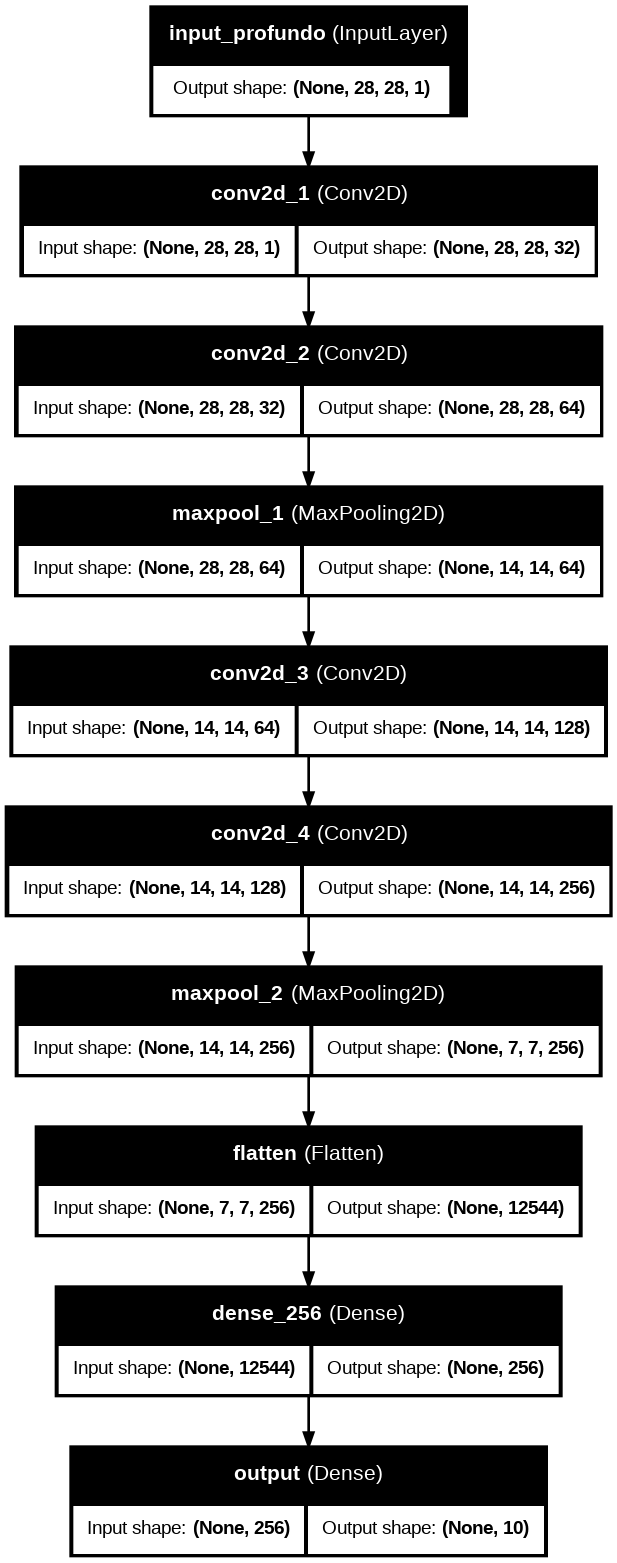

In [5]:
import pydot
pydot.find_graphviz = lambda: True  # truco para que no falle

from tensorflow.keras.utils import plot_model
from IPython.display import Image

plot_model(
    cnn_profundo,
    to_file="convnet.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)
Image(filename="convnet.png")

In [6]:
# ============================================
# 3) ENTRENAMIENTO
# ============================================
epochs = 50        # Ajusta según recurso (Colab GPU: sube si quieres)
batch_size = 128

# Entrenamos la CNN profunda (mismas condiciones)
history_profundo = cnn_profundo.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.8851 - loss: 0.3570 - val_accuracy: 0.9878 - val_loss: 0.0460
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9877 - loss: 0.0393 - val_accuracy: 0.9908 - val_loss: 0.0350
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9924 - loss: 0.0238 - val_accuracy: 0.9902 - val_loss: 0.0353
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9905 - val_loss: 0.0335
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9902 - val_loss: 0.0502
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9966 - loss: 0.0103 - val_accuracy: 0.9918 - val_loss: 0.0415
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9972 - loss: 0.0089 - val_accuracy: 0.9913 - val_loss: 0.0385
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9975 - loss: 0.0075 - val_acc

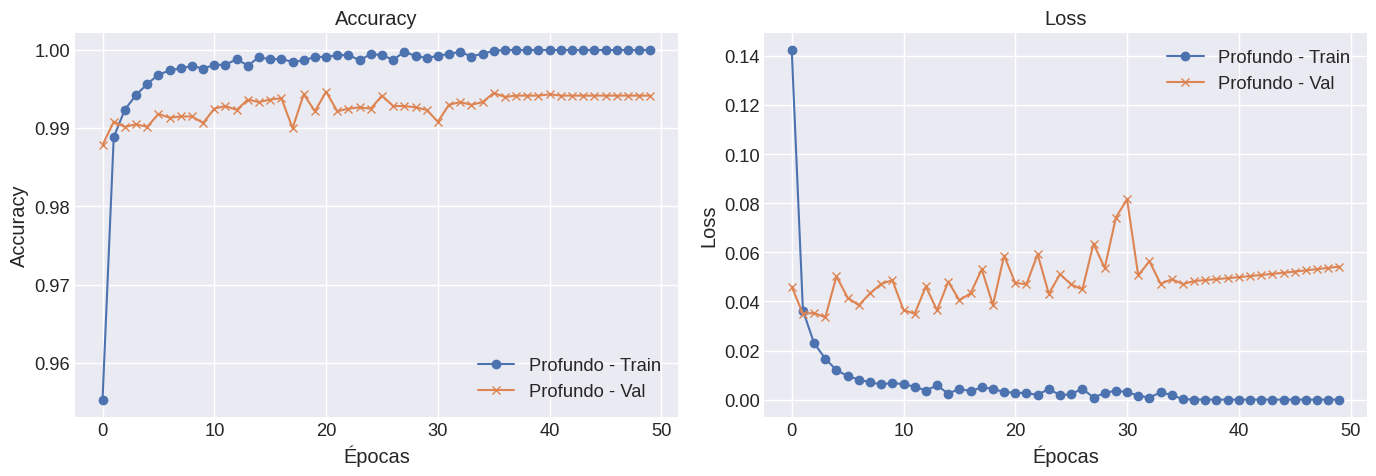

In [7]:
# ============================================
# 4) COMPARACIÓN VISUAL: Accuracy y Loss
# ============================================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_profundo.history['accuracy'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_accuracy'], marker='x', label='Profundo - Val')
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_profundo.history['loss'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_loss'], marker='x', label='Profundo - Val')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



=== CNN Profundo: 4 capas convolucionales detectadas ===

Procesando capa: conv2d_1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


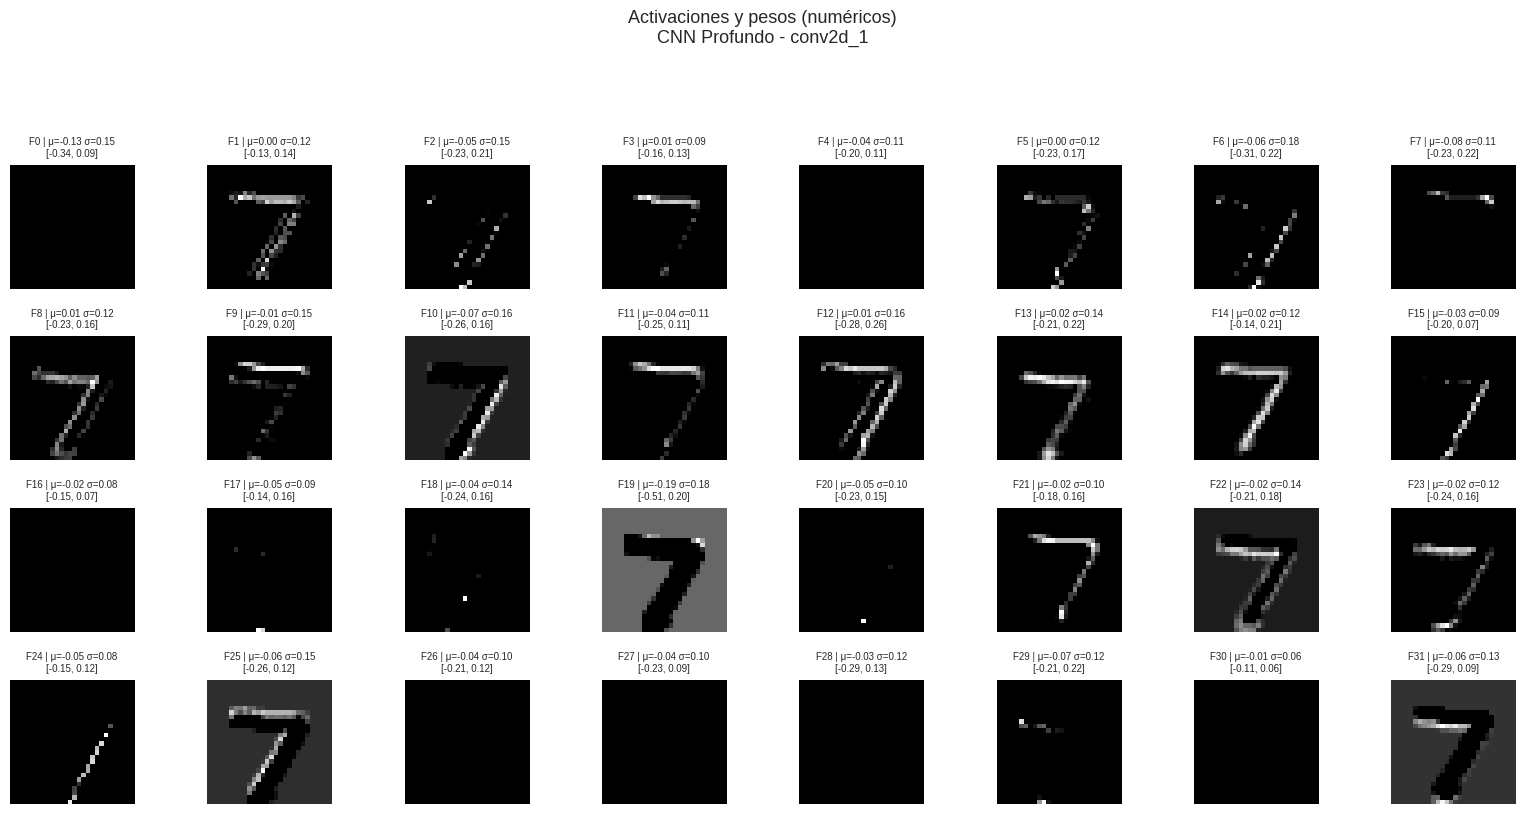

Procesando capa: conv2d_2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


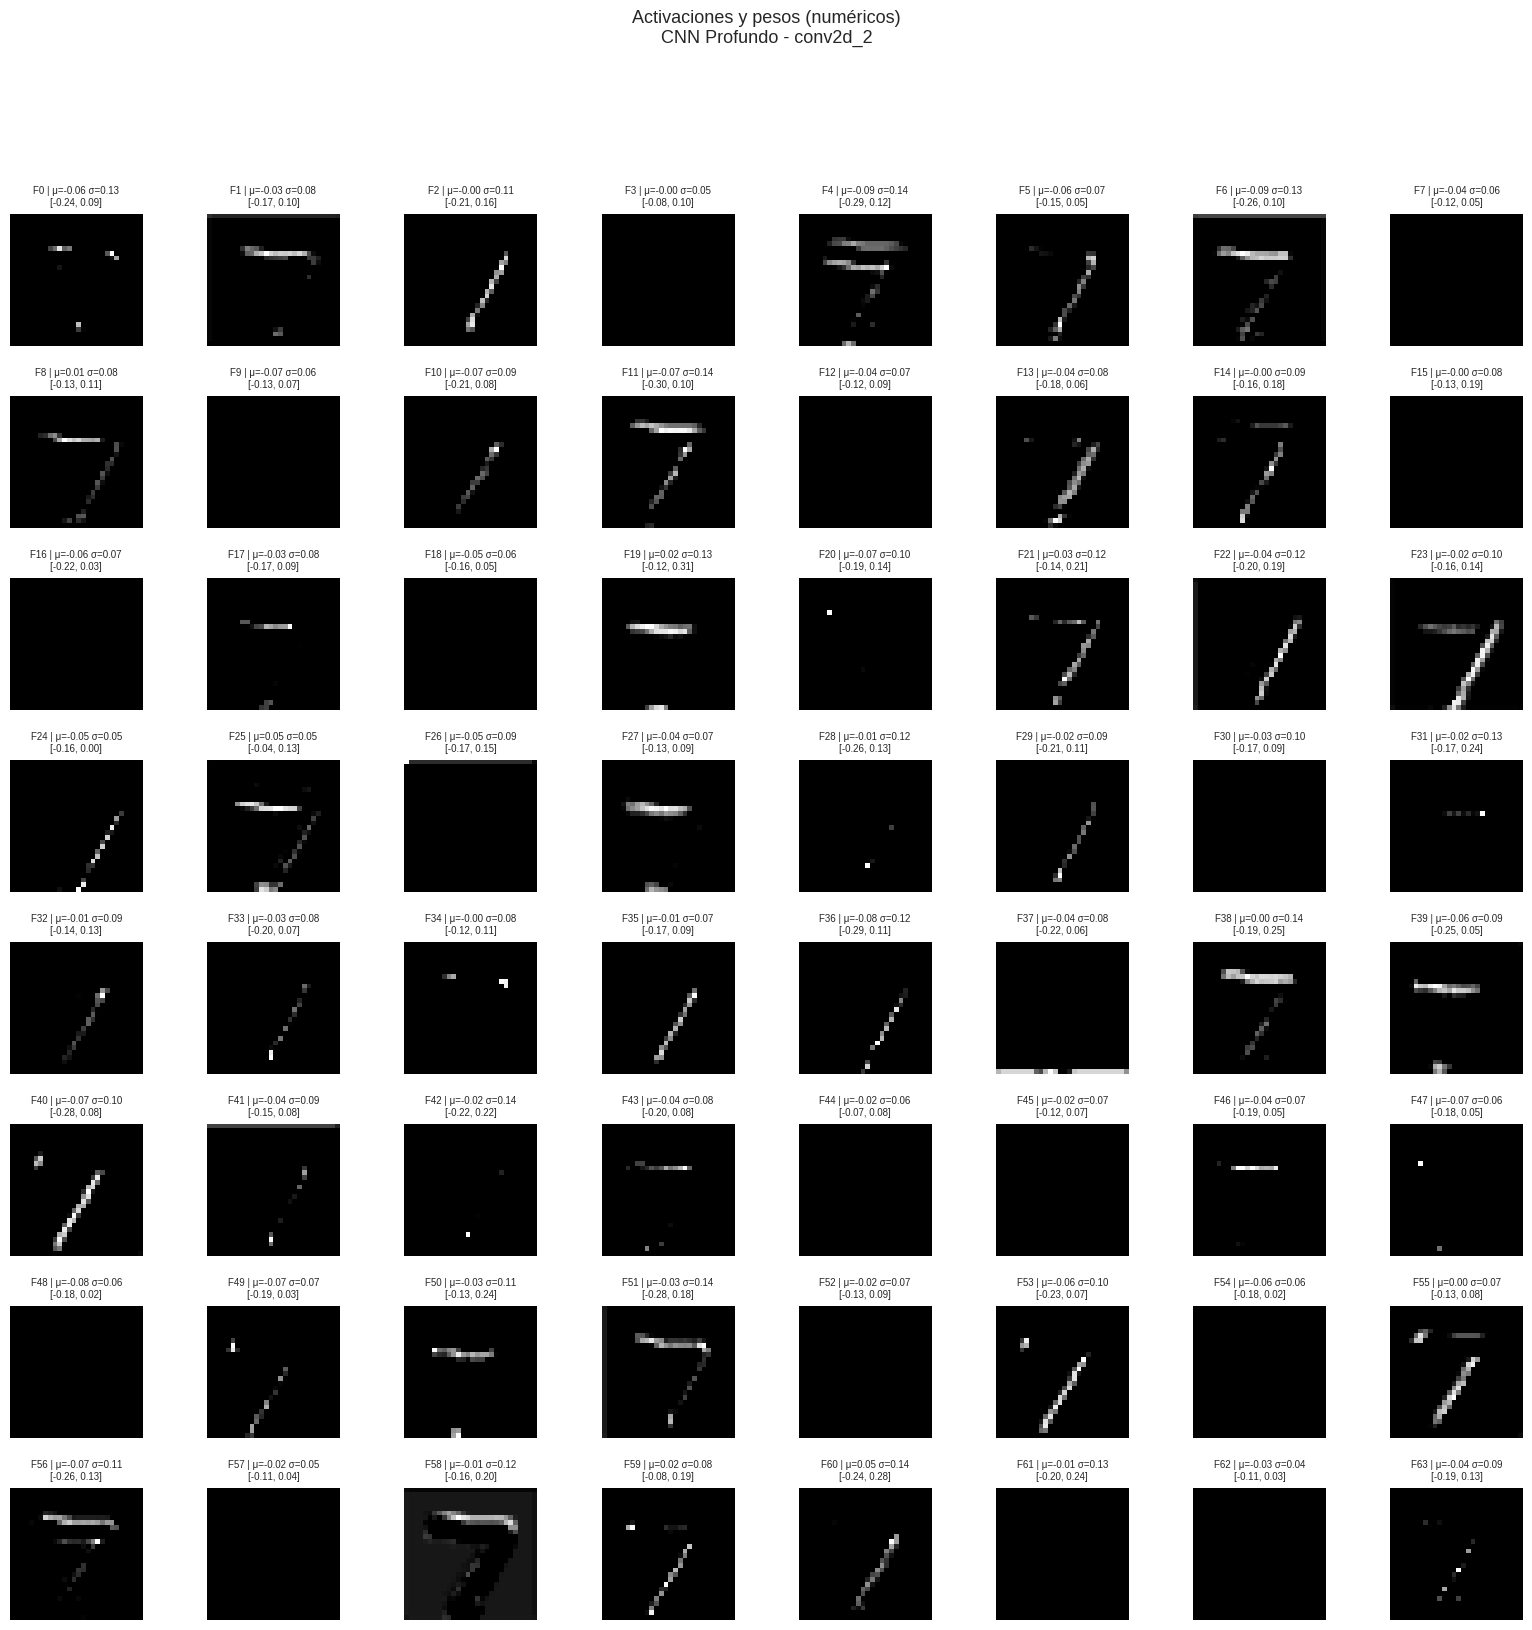

Procesando capa: conv2d_3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


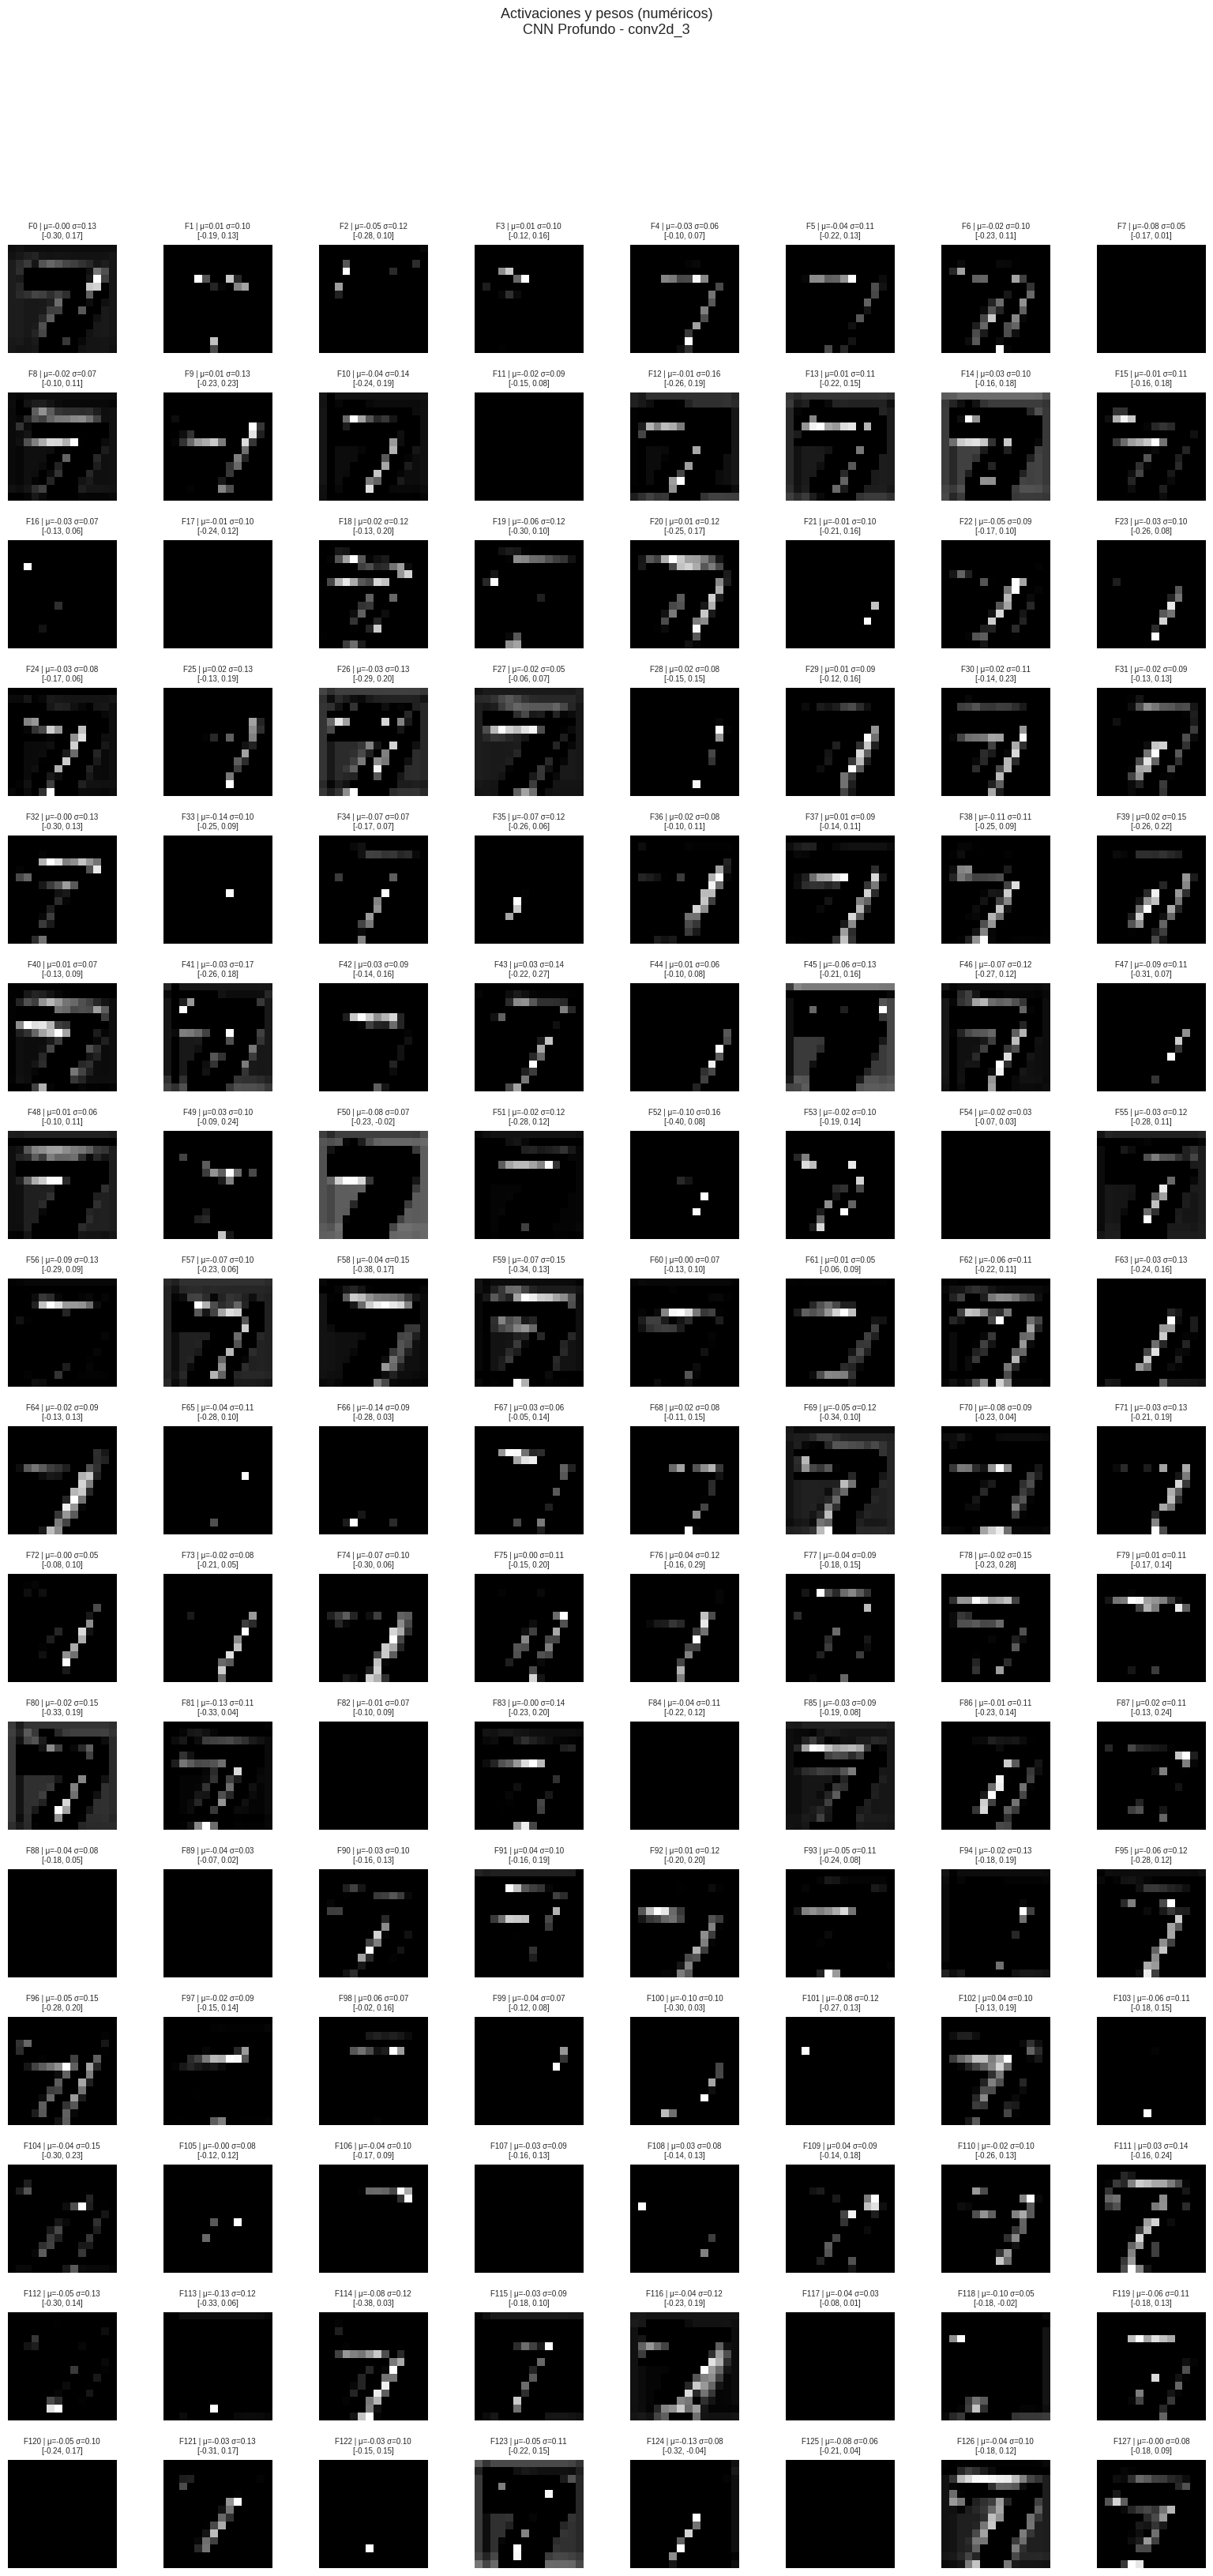

Procesando capa: conv2d_4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


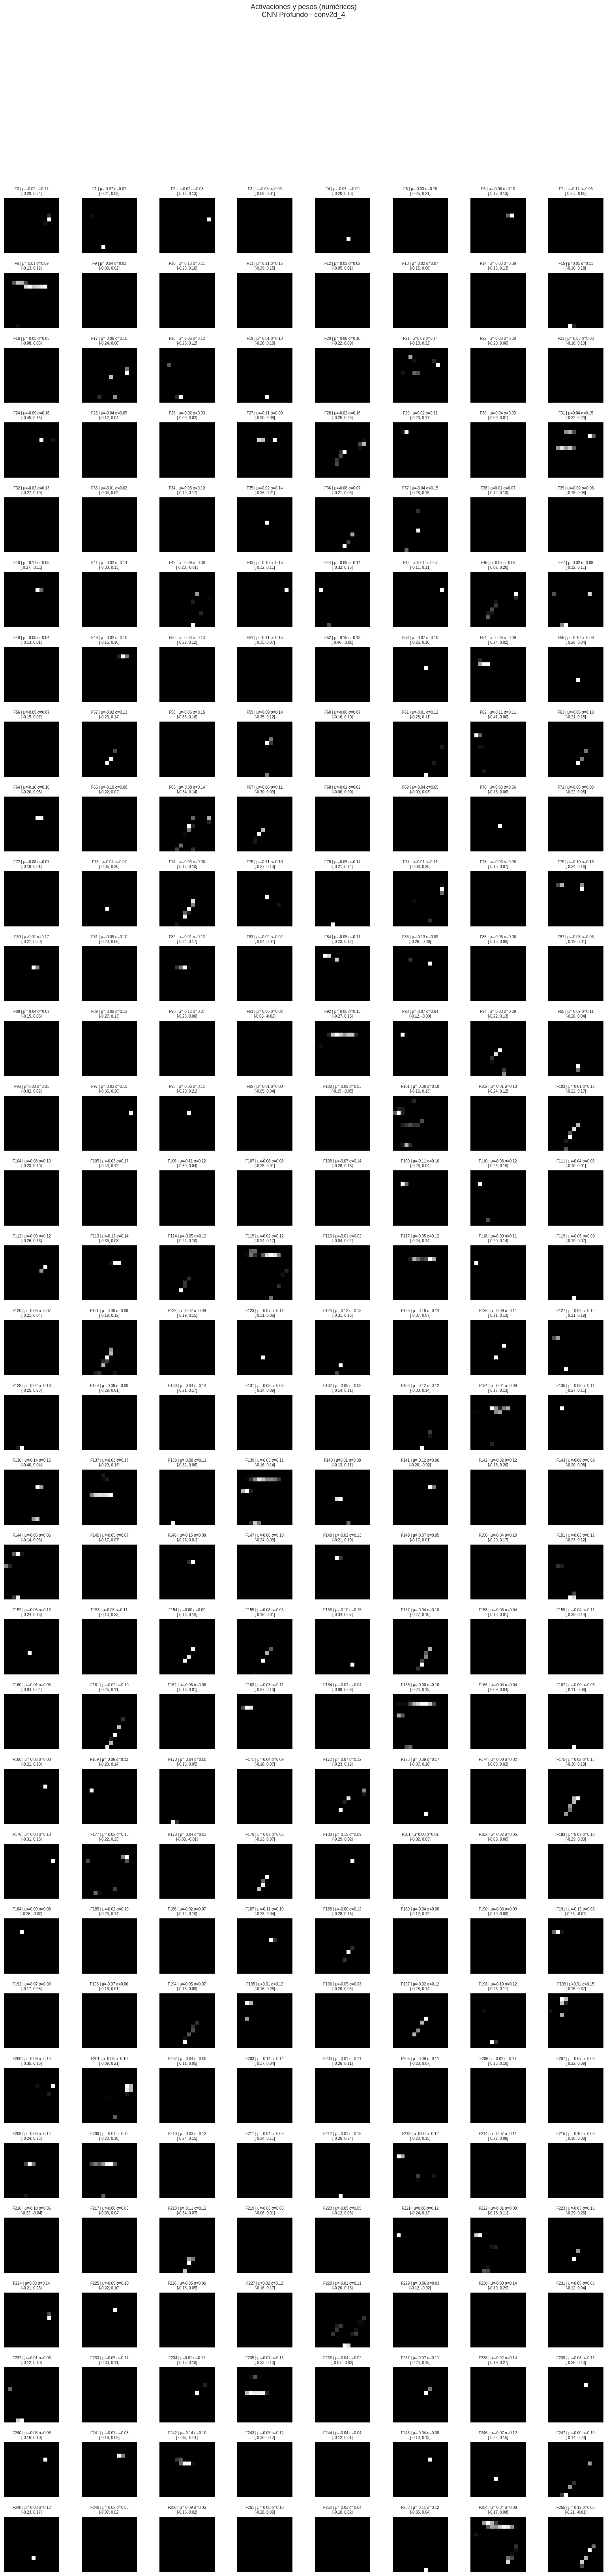

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import mnist
import numpy as np

# Cargar datos MNIST
(_, _), (x_test, _) = mnist.load_data()

# Seleccionar una imagen de prueba y darle forma correcta
base_img = x_test[0].astype('float32') / 255.0
base_img = np.expand_dims(base_img, axis=-1)  # Añadir canal (28,28,1)


def plot_conv_filters(model, img, layer_name, model_name="CNN"):

    if img.ndim == 3:
        img = img[np.newaxis, ...]

    layer = model.get_layer(layer_name)
    weights, biases = layer.get_weights()
    act_model = Model(inputs=model.input, outputs=layer.output)
    activations = act_model.predict(img)[0]

    n_filters = activations.shape[-1]
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_filters):
        kernel = weights[:, :, 0, i]
        mean_w = np.mean(kernel)
        std_w = np.std(kernel)
        min_w = np.min(kernel)
        max_w = np.max(kernel)

        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activations[:, :, i], cmap='gray')
        plt.axis('off')
        plt.title(f"F{i} | μ={mean_w:.2f} σ={std_w:.2f}\n[{min_w:.2f}, {max_w:.2f}]", fontsize=7)

    # --- Ajuste del espaciado del título ---
    plt.suptitle(f"Activaciones y pesos (numéricos)\n{model_name} - {layer_name}", fontsize=13, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_all_conv_layers(model, img, model_name="CNN"):
    """
    Muestra las activaciones y pesos numéricos de todas las capas Conv2D de un modelo.
    """
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    if not conv_layers:
        print(f"{model_name}: No se encontraron capas convolucionales.")
        return

    print(f"\n=== {model_name}: {len(conv_layers)} capas convolucionales detectadas ===\n")
    for lname in conv_layers:
        print(f"Procesando capa: {lname}")
        plot_conv_filters(model, img, lname, model_name)


# --- Uso ---
plot_all_conv_layers(cnn_profundo, base_img, "CNN Profundo")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


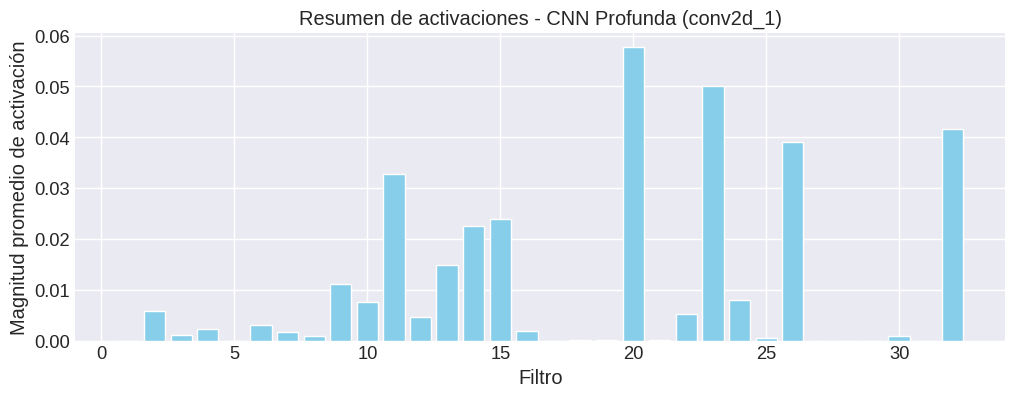

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


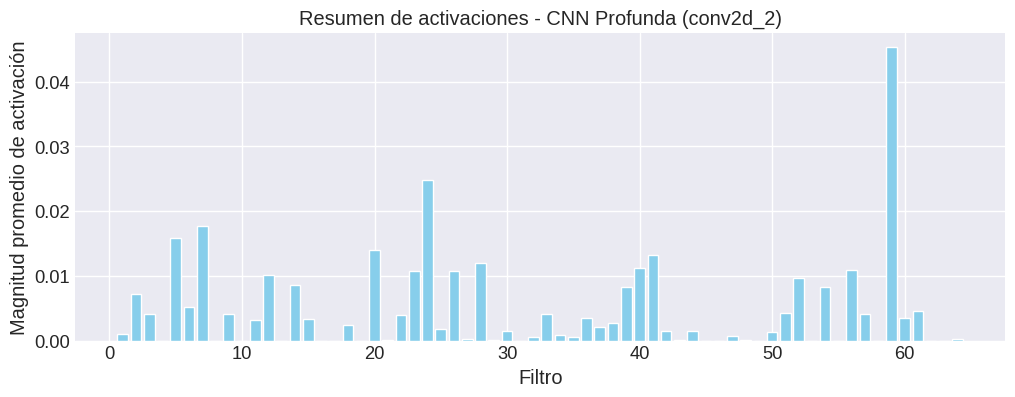

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


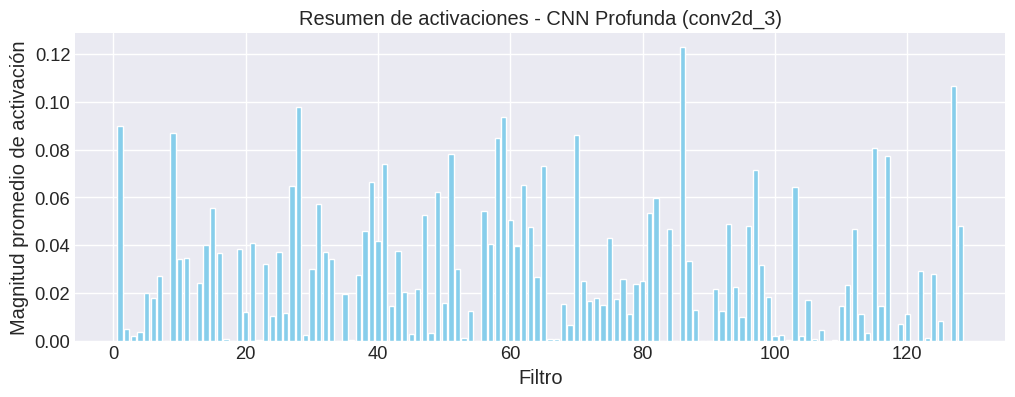

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


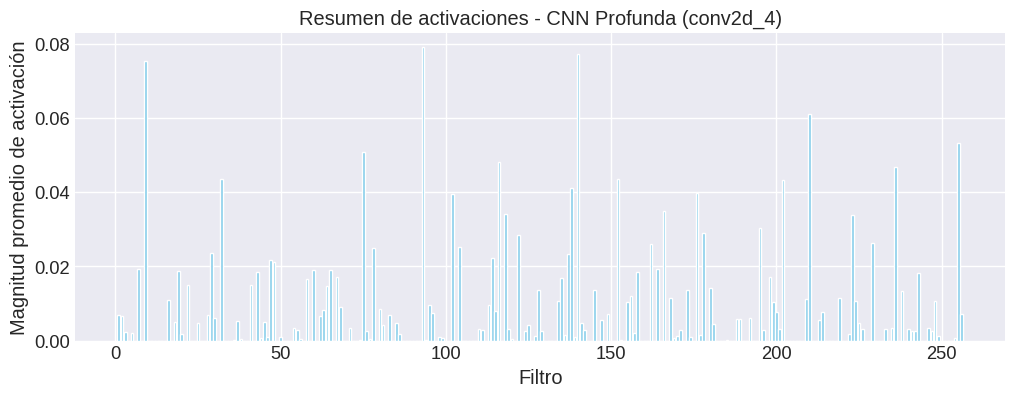

In [9]:
def plot_activation_summary(model, img, layer_name, model_name="CNN"):
    from tensorflow.keras.models import Model
    import matplotlib.pyplot as plt
    import numpy as np

    # Aseguramos batch
    if img.ndim == 3:
        img = img.reshape(1, *img.shape)

    # Modelo intermedio para activaciones
    conv_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    activations = conv_model.predict(img)  # shape: (1,H,W,C)

    # Promedio absoluto de activaciones por filtro
    avg_activations = np.mean(np.abs(activations), axis=(1,2))  # shape: (1,C)
    avg_activations = avg_activations.flatten()

    # Gráfica
    plt.figure(figsize=(12,4))
    plt.bar(range(1, len(avg_activations)+1), avg_activations, color='skyblue')
    plt.xlabel("Filtro")
    plt.ylabel("Magnitud promedio de activación")
    plt.title(f"Resumen de activaciones - {model_name} ({layer_name})")
    plt.show()

plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_1", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_2", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_3", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_4", model_name="CNN Profunda")


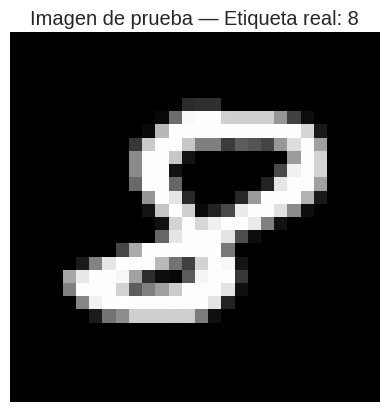

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
✅ Clase real: 8 — Clase predicha: 8
Predicciones: [[6.3568784e-29 4.2558883e-37 4.0091157e-19 9.2564532e-26 2.3392636e-34
  5.7680090e-30 2.5644223e-32 2.8581744e-36 1.0000000e+00 2.8412847e-26]]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# ============================================
# 1️⃣ Cargar y preparar MNIST
# ============================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalización y expansión de canal
x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1)  # (28,28,1)
y_test_cat = to_categorical(y_test, 10)

# ============================================
# 2️⃣ Cargar tu modelo CNN Profundo
# ============================================
# (Si ya lo definiste en tu notebook, solo asegúrate de que cnn_profundo esté entrenado)
# cnn_profundo.load_weights('pesos_cnn_profundo.h5')  # si ya tienes pesos guardados

# ============================================
# 3️⃣ Seleccionar y mostrar una imagen de prueba
# ============================================
idx = 61 # puedes cambiar el índice
img = x_test[idx]
label = y_test[idx]

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Imagen de prueba — Etiqueta real: {label}')
plt.axis('off')
plt.show()

# ============================================
# 4️⃣ Realizar la predicción con tu modelo
# ============================================
img_array = np.expand_dims(img, axis=0)
preds = cnn_profundo.predict(img_array)
predicted_class = np.argmax(preds[0])

print(f"✅ Clase real: {label} — Clase predicha: {predicted_class}")
print("Predicciones:", preds)


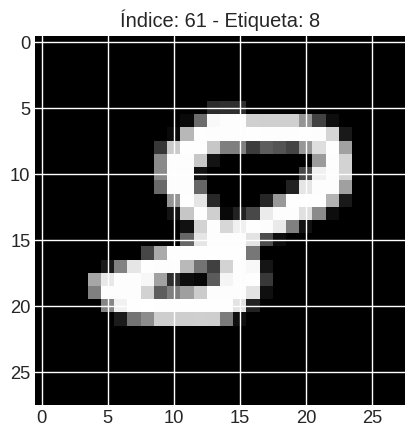

Primer índice con un 8 en el conjunto de prueba: 61


In [11]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Encontrar índice donde la etiqueta es 8 (en el conjunto de prueba)
indices_8 = [i for i, label in enumerate(y_test) if label == 8]

# Mostrar el primer ejemplo encontrado
idx = indices_8[0]
plt.imshow(x_test[idx], cmap='gray')  # <-- corregido: usar x_test
plt.title(f"Índice: {idx} - Etiqueta: {y_test[idx]}")
plt.show()

print(f"Primer índice con un 8 en el conjunto de prueba: {idx}")



In [12]:
def get_img_array(img_path, size=(299, 299)):
    # `img` is a PIL image of size 299x299
    img = keras.utils.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.utils.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(array, axis=0)
    return array


def get_gradients(img_input, top_pred_idx):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        img_input: 4D image tensor
        top_pred_idx: Predicted label for the input image

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    images = tf.cast(img_input, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(images)
        preds = model(images)
        top_class = preds[:, top_pred_idx]

    grads = tape.gradient(top_class, images)
    return grads


def get_integrated_gradients(img_input, top_pred_idx, baseline=None, num_steps=50):
    """Computes Integrated Gradients for a predicted label.

    Args:
        img_input (ndarray): Original image
        top_pred_idx: Predicted label for the input image
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with a black image
    # having same size as the input image.
    if baseline is None:
        baseline = np.zeros(img_size).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)

    # 1. Do interpolation.
    img_input = img_input.astype(np.float32)
    interpolated_image = [
        baseline + (step / num_steps) * (img_input - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_image = np.array(interpolated_image).astype(np.float32)

    # 2. Preprocess the interpolated images
    interpolated_image = xception.preprocess_input(interpolated_image)

    # 3. Get the gradients
    grads = []
    for i, img in enumerate(interpolated_image):
        img = tf.expand_dims(img, axis=0)
        grad = get_gradients(img, top_pred_idx=top_pred_idx)
        grads.append(grad[0])
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)

    # 5. Calculate integrated gradients and return
    integrated_grads = (img_input - baseline) * avg_grads
    return integrated_grads


def random_baseline_integrated_gradients(
    img_input, top_pred_idx, num_steps=50, num_runs=2
):
    """Generates a number of random baseline images.

    Args:
        img_input (ndarray): 3D image
        top_pred_idx: Predicted label for the input image
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        num_runs: number of baseline images to generate

    Returns:
        Averaged integrated gradients for `num_runs` baseline images
    """
    # 1. List to keep track of Integrated Gradients (IG) for all the images
    integrated_grads = []

    # 2. Get the integrated gradients for all the baselines
    for run in range(num_runs):
        baseline = np.random.random(img_size) * 255
        igrads = get_integrated_gradients(
            img_input=img_input,
            top_pred_idx=top_pred_idx,
            baseline=baseline,
            num_steps=num_steps,
        )
        integrated_grads.append(igrads)

    # 3. Return the average integrated gradients for the image
    integrated_grads = tf.convert_to_tensor(integrated_grads)
    return tf.reduce_mean(integrated_grads, axis=0)

In [13]:
class GradVisualizer:
    """Plot gradients of the outputs w.r.t an input image."""

    def __init__(self, positive_channel=None, negative_channel=None):
        if positive_channel is None:
            self.positive_channel = [0, 255, 0]
        else:
            self.positive_channel = positive_channel

        if negative_channel is None:
            self.negative_channel = [255, 0, 0]
        else:
            self.negative_channel = negative_channel

    def apply_polarity(self, attributions, polarity):
        if polarity == "positive":
            return np.clip(attributions, 0, 1)
        else:
            return np.clip(attributions, -1, 0)

    def apply_linear_transformation(
        self,
        attributions,
        clip_above_percentile=99.9,
        clip_below_percentile=70.0,
        lower_end=0.2,
    ):
        # 1. Get the thresholds
        m = self.get_thresholded_attributions(
            attributions, percentage=100 - clip_above_percentile
        )
        e = self.get_thresholded_attributions(
            attributions, percentage=100 - clip_below_percentile
        )

        # 2. Transform the attributions by a linear function f(x) = a*x + b such that
        # f(m) = 1.0 and f(e) = lower_end
        transformed_attributions = (1 - lower_end) * (np.abs(attributions) - e) / (
            m - e
        ) + lower_end

        # 3. Make sure that the sign of transformed attributions is the same as original attributions
        transformed_attributions *= np.sign(attributions)

        # 4. Only keep values that are bigger than the lower_end
        transformed_attributions *= transformed_attributions >= lower_end

        # 5. Clip values and return
        transformed_attributions = np.clip(transformed_attributions, 0.0, 1.0)
        return transformed_attributions

    def get_thresholded_attributions(self, attributions, percentage):
        if percentage == 100.0:
            return np.min(attributions)

        # 1. Flatten the attributions
        flatten_attr = attributions.flatten()

        # 2. Get the sum of the attributions
        total = np.sum(flatten_attr)

        # 3. Sort the attributions from largest to smallest.
        sorted_attributions = np.sort(np.abs(flatten_attr))[::-1]

        # 4. Calculate the percentage of the total sum that each attribution
        # and the values about it contribute.
        cum_sum = 100.0 * np.cumsum(sorted_attributions) / total

        # 5. Threshold the attributions by the percentage
        indices_to_consider = np.where(cum_sum >= percentage)[0][0]

        # 6. Select the desired attributions and return
        attributions = sorted_attributions[indices_to_consider]
        return attributions

    def binarize(self, attributions, threshold=0.001):
        return attributions > threshold

    def morphological_cleanup_fn(self, attributions, structure=np.ones((4, 4))):
        closed = ndimage.grey_closing(attributions, structure=structure)
        opened = ndimage.grey_opening(closed, structure=structure)
        return opened

    def draw_outlines(
        self,
        attributions,
        percentage=90,
        connected_component_structure=np.ones((3, 3)),
    ):
        # 1. Binarize the attributions.
        attributions = self.binarize(attributions)

        # 2. Fill the gaps
        attributions = ndimage.binary_fill_holes(attributions)

        # 3. Compute connected components
        connected_components, num_comp = ndimage.label(
            attributions, structure=connected_component_structure
        )

        # 4. Sum up the attributions for each component
        total = np.sum(attributions[connected_components > 0])
        component_sums = []
        for comp in range(1, num_comp + 1):
            mask = connected_components == comp
            component_sum = np.sum(attributions[mask])
            component_sums.append((component_sum, mask))

        # 5. Compute the percentage of top components to keep
        sorted_sums_and_masks = sorted(component_sums, key=lambda x: x[0], reverse=True)
        sorted_sums = list(zip(*sorted_sums_and_masks))[0]
        cumulative_sorted_sums = np.cumsum(sorted_sums)
        cutoff_threshold = percentage * total / 100
        cutoff_idx = np.where(cumulative_sorted_sums >= cutoff_threshold)[0][0]
        if cutoff_idx > 2:
            cutoff_idx = 2

        # 6. Set the values for the kept components
        border_mask = np.zeros_like(attributions)
        for i in range(cutoff_idx + 1):
            border_mask[sorted_sums_and_masks[i][1]] = 1

        # 7. Make the mask hollow and show only the border
        eroded_mask = ndimage.binary_erosion(border_mask, iterations=1)
        border_mask[eroded_mask] = 0

        # 8. Return the outlined mask
        return border_mask

    def process_grads(
        self,
        image,
        attributions,
        polarity="positive",
        clip_above_percentile=99.9,
        clip_below_percentile=0,
        morphological_cleanup=False,
        structure=np.ones((3, 3)),
        outlines=False,
        outlines_component_percentage=90,
        overlay=True,
    ):
        if polarity not in ["positive", "negative"]:
            raise ValueError(
                f""" Allowed polarity values: 'positive' or 'negative'
                                    but provided {polarity}"""
            )
        if clip_above_percentile < 0 or clip_above_percentile > 100:
            raise ValueError("clip_above_percentile must be in [0, 100]")

        if clip_below_percentile < 0 or clip_below_percentile > 100:
            raise ValueError("clip_below_percentile must be in [0, 100]")

        # 1. Apply polarity
        if polarity == "positive":
            attributions = self.apply_polarity(attributions, polarity=polarity)
            channel = self.positive_channel
        else:
            attributions = self.apply_polarity(attributions, polarity=polarity)
            attributions = np.abs(attributions)
            channel = self.negative_channel

        # 2. Take average over the channels
        attributions = np.average(attributions, axis=2)

        # 3. Apply linear transformation to the attributions
        attributions = self.apply_linear_transformation(
            attributions,
            clip_above_percentile=clip_above_percentile,
            clip_below_percentile=clip_below_percentile,
            lower_end=0.0,
        )

        # 4. Cleanup
        if morphological_cleanup:
            attributions = self.morphological_cleanup_fn(
                attributions, structure=structure
            )
        # 5. Draw the outlines
        if outlines:
            attributions = self.draw_outlines(
                attributions, percentage=outlines_component_percentage
            )

        # 6. Expand the channel axis and convert to RGB
        attributions = np.expand_dims(attributions, 2) * channel

        # 7.Superimpose on the original image
        if overlay:
            attributions = np.clip((attributions * 0.8 + image), 0, 255)
        return attributions

    def visualize(
        self,
        image,
        gradients,
        integrated_gradients,
        polarity="positive",
        clip_above_percentile=99.9,
        clip_below_percentile=0,
        morphological_cleanup=False,
        structure=np.ones((3, 3)),
        outlines=False,
        outlines_component_percentage=90,
        overlay=True,
        figsize=(15, 8),
    ):
        # 1. Make two copies of the original image
        img1 = np.copy(image)
        img2 = np.copy(image)

        # 2. Process the normal gradients
        grads_attr = self.process_grads(
            image=img1,
            attributions=gradients,
            polarity=polarity,
            clip_above_percentile=clip_above_percentile,
            clip_below_percentile=clip_below_percentile,
            morphological_cleanup=morphological_cleanup,
            structure=structure,
            outlines=outlines,
            outlines_component_percentage=outlines_component_percentage,
            overlay=overlay,
        )

        # 3. Process the integrated gradients
        igrads_attr = self.process_grads(
            image=img2,
            attributions=integrated_gradients,
            polarity=polarity,
            clip_above_percentile=clip_above_percentile,
            clip_below_percentile=clip_below_percentile,
            morphological_cleanup=morphological_cleanup,
            structure=structure,
            outlines=outlines,
            outlines_component_percentage=outlines_component_percentage,
            overlay=overlay,
        )

        _, ax = plt.subplots(1, 3, figsize=figsize)
        ax[0].imshow(image)
        ax[1].imshow(grads_attr.astype(np.uint8))
        ax[2].imshow(igrads_attr.astype(np.uint8))

        ax[0].set_title("Input")
        ax[1].set_title("Normal gradients")
        ax[2].set_title("Integrated gradients")
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
✅ Clase real: 8 — Clase predicha: 8
Predicciones: [[6.3568784e-29 4.2558883e-37 4.0091157e-19 9.2564532e-26 2.3392636e-34
  5.7680090e-30 2.5644223e-32 2.8581744e-36 1.0000000e+00 2.8412847e-26]]


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_profundo']]
Received: inputs=['Tensor(shape=(1, 28, 28, 1))']
  warnings.warn(msg)


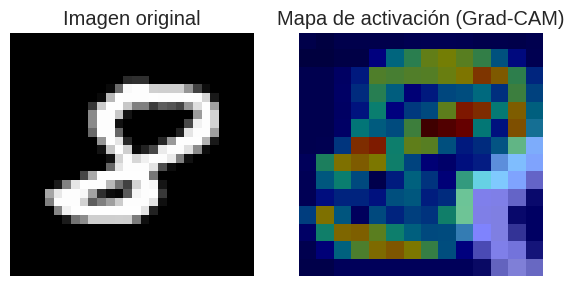

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================
# 1️⃣ Convertir la imagen (ya cargada de MNIST) a arreglo compatible
# ============================================
img_array = np.expand_dims(img, axis=0)  # (1, 28, 28, 1)
orig_img = np.copy(img.squeeze())  # copia para mostrar

# ============================================
# 2️⃣ Obtener predicciones del modelo
# ============================================
preds = cnn_profundo.predict(img_array)
top_pred_idx = tf.argmax(preds[0])

print(f"✅ Clase real: {label} — Clase predicha: {top_pred_idx.numpy()}")
print("Predicciones:", preds)

# ============================================
# 3️⃣ Calcular gradientes (Grad-CAM base)
# ============================================
# Escogemos la última capa convolucional
last_conv_layer = cnn_profundo.get_layer("conv2d_3")

# Usamos GradientTape para obtener gradientes
with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    tape.watch(inputs)
    last_conv_output, preds_output = tf.keras.models.Model(
        [cnn_profundo.inputs],
        [last_conv_layer.output, cnn_profundo.output]
    )(inputs)
    loss = preds_output[:, top_pred_idx]

# Gradientes respecto a la última capa
grads = tape.gradient(loss, last_conv_output)

# ============================================
# 4️⃣ Generar el mapa de activación
# ============================================
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = tf.reduce_mean(tf.multiply(pooled_grads, last_conv_output), axis=-1)[0]

# Normalización
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

# ============================================
# 5️⃣ Visualizar Grad-CAM
# ============================================
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(orig_img, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(orig_img, cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Mapa de activación (Grad-CAM)")
plt.axis("off")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
✅ Clase real: 8 — Clase predicha: 8
Predicciones: [[6.3568784e-29 4.2558883e-37 4.0091157e-19 9.2564532e-26 2.3392636e-34
  5.7680090e-30 2.5644223e-32 2.8581744e-36 1.0000000e+00 2.8412847e-26]]


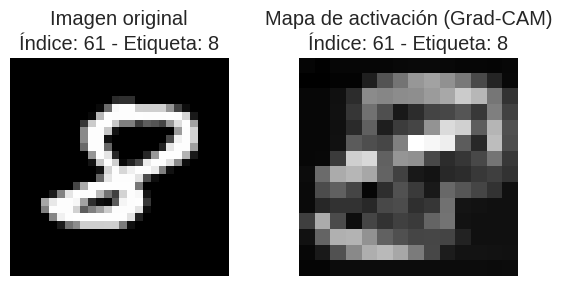

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================
# 1️⃣ Convertir la imagen (ya cargada de MNIST) a arreglo compatible
# ============================================
img_array = np.expand_dims(img, axis=0)  # (1, 28, 28, 1)
orig_img = np.copy(img.squeeze())  # copia para mostrar

# ============================================
# 2️⃣ Obtener predicciones del modelo
# ============================================
preds = cnn_profundo.predict(img_array)
top_pred_idx = tf.argmax(preds[0])

print(f"✅ Clase real: {label} — Clase predicha: {top_pred_idx.numpy()}")
print("Predicciones:", preds)

# ============================================
# 3️⃣ Calcular gradientes (Grad-CAM base)
# ============================================
# Escogemos la última capa convolucional
last_conv_layer = cnn_profundo.get_layer("conv2d_3")

# Usamos GradientTape para obtener gradientes
with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    tape.watch(inputs)
    last_conv_output, preds_output = tf.keras.models.Model(
        [cnn_profundo.inputs],
        [last_conv_layer.output, cnn_profundo.output]
    )(inputs)
    loss = preds_output[:, top_pred_idx]

# Gradientes respecto a la última capa
grads = tape.gradient(loss, last_conv_output)

# ============================================
# 4️⃣ Generar el mapa de activación
# ============================================
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = tf.reduce_mean(tf.multiply(pooled_grads, last_conv_output), axis=-1)[0]

# Normalización
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

# ============================================
# 5️⃣ Visualizar Grad-CAM
# ============================================
titulo = f"Índice: {idx} - Etiqueta: {y_test[idx]}"

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(orig_img, cmap='gray')
plt.title(f"Imagen original\n{titulo}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='gray', alpha=1)
plt.title(f"Mapa de activación (Grad-CAM)\n{titulo}")
plt.axis("off")

plt.tight_layout()
plt.show()


## 📚 Referencias

- Chollet, F. (2017). *Xception: Deep Learning with Depthwise Separable Convolutions.*
- Keras — documentación oficial: https://keras.io/ (consultar `keras.applications` y `layers`).
- Keras Applications (Xception): https://keras.io/api/applications/xception/
- TensorFlow — guía `tf.keras`: https://www.tensorflow.org/guide/keras
- Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* ICCV.
- MNIST dataset — Yann LeCun: http://yann.lecun.com/exdb/mnist/
